PREGUNTAS A RESPONDER:
-CUALES SON LAS VARIABLES QUE DETERMINAN QUE UN EQUIPO SEA MEJOR QUE OTRO EN UNA TEMPORADA?
-Clustering: Agrupar equipos según su eficiencia (goles/tiros, goles/posesión, etc.) para ver qué grupos de equipos son más efectivos.(Identificacion patrones de eficacia). Podriamos resolver valores atipicos en base a comapraciones finales
-Clustering: Equipos con estilos similares (segun variables)
-Clustering ¿Qué jugadores o equipos generan más acciones clave (pases, tiros, recuperaciones) en los partidos? - jugadores mas influyentes segun registros, que equipos dependen de mas acciones individuales
-Partidos mas taquilleros (se puede??)
-¿Qué equipos recibieron más presión en campo rival?
-¿En qué minutos se concentran más goles en la liga/torneo?
-EXPLORATORIO/OUTLIERS: ¿Qué jugadores generan valores atípicos en volumen de acciones clave (ej. un mediocampista con más recuperaciones que el promedio de su liga)?

-PREDECIR EQUIPO CAMPEON 2025/2026

UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (ANALISIS MÁS CLASICO)
UNION DE DATASET: COMPETITIONS + MATCHES + EVENTS (MÁS GRANULAR (ANALISIS ESPACIAL Y DINAMICO (TRACKING)))

In [2]:
#libraries
#pip install statsbombpy - libreria de Hudl
#pip install mplsoccer - traza de canchas, graficos (radar, pizza, cambios en el tiempo, etc), flechas, mapas de calor, entre otros.
#URL MPLSOCCER DOCS: https://mplsoccer.readthedocs.io/en/latest/
#pakcs
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [3]:
#aspectos principales de la libreria statsbombs
#datasets principales: competitios, matches, events, lineups, frames
#ver la doc de cada funcion -> help(sb.competitions)
dir(sb)

['DEFAULT_CREDS',
 'MAX_CONCURRENCY',
 'Pool',
 'Union',
 '_360_frames',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'api_client',
 'competition_events',
 'competition_frames',
 'competitions',
 'events',
 'filter_and_group_events',
 'frames',
 'lineups',
 'matches',
 'merge_events_and_frames',
 'partial',
 'pd',
 'player_match_stats',
 'player_season_stats',
 'public',
 'reduce_events',
 'team_match_stats',
 'team_season_stats']

In [13]:
#LaLiga => competition_id=11; TENEMOS 17 TEMPORADAS
#VARIABLES A DEJAR: competition_id; season_id; competition_name; season_name
#seasons = [[37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]] - seasons_id
competitions = sb.competitions();
la_liga = competitions[competitions["competition_id"]==11];
la_liga.head(17)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
39,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
40,11,4,Spain,La Liga,male,False,False,2018/2019,2024-09-22T18:50:23.364757,2021-07-09T14:53:22.103024,None,2024-09-22T18:50:23.364757
41,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
42,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
43,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
44,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
45,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
46,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
47,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


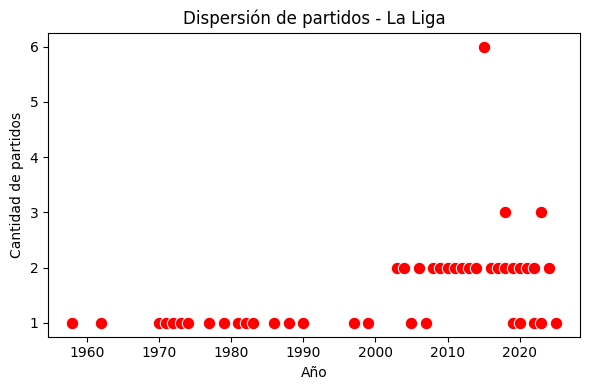

In [14]:
#cuenteo de partidos por temp
partidos_x_temp = competitions.groupby('season_name').size().reset_index(name='cantidad_partidos')
#Prueba grafica (x,y) donde se visualicen cant de partidos por año
partidos_x_temp['season_year'] = partidos_x_temp['season_name'].str[:4].astype(int)

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='season_year', 
    y='cantidad_partidos', 
    data=partidos_x_temp,
    s=80, color='red'
)
plt.xlabel('Año')
plt.ylabel('Cantidad de partidos')
plt.title('Dispersión de partidos - La Liga')
plt.tight_layout()
plt.show()


In [ ]:
#variables - matches
#DEJAR EN EL DATASET: match_date; home_team; away_team;home_score; away_score; match_week; competition_stage; stadium; home_managers; away_managers
matches = sb.matches(competition_id=11,season_id=90);
matches.head(1)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,...,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


In [ ]:
# Cargar los eventos del partido
#87 variables
events = sb.events(match_id=3754037) 
events.columns

Index(['ball_receipt_outcome', 'ball_recovery_offensive',
       'ball_recovery_recovery_failure', 'carry_end_location',
       'clearance_aerial_won', 'clearance_body_part', 'clearance_head',
       'clearance_left_foot', 'clearance_right_foot', 'counterpress',
       'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id',
       'index', 'interception_outcome', 'location', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross',
       'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height',
   

In [16]:
#merge de competitions + matches (mediante competition_id y season_id)
competition_id = 11
seasons = [37,38,39,40,41,21,22,23,24,25,26,27,2,1,4,42,90]

competitions_reduce = sb.competitions()[['competition_id','season_id',
                                'competition_name','season_name','country_name']].drop_duplicates()

all_matches = []
for sid in seasons:
    m = sb.matches(competition_id=competition_id, season_id=sid)
    m['competition_id'] = 11
    m['season_id'] = sid

    m = m[['match_id','competition_id','season_id','match_date',
           'home_team','away_team','home_score','away_score',
           'match_week','competition_stage','stadium',
           'home_managers','away_managers']].copy()
    all_matches.append(m)

matches_df = pd.concat(all_matches, ignore_index=True)
# Ordenar por fecha descendente
matches_df = matches_df.sort_values('match_date', ascending=False).reset_index(drop=True)
# #sid == season_id
# #m == matches

merged = matches_df.merge(competitions_reduce, on=['competition_id','season_id'], how='left')

print(merged.shape)
merged


(867, 16)


,match_id,competition_id,season_id,match_date,home_team,away_team,home_score,away_score,match_week,competition_stage,stadium,home_managers,away_managers,competition_name,season_name,country_name
0,3773457,11,90,2021-05-16,Barcelona,Celta Vigo,1,2,37,Regular Season,Spotify Camp Nou,Ronald Koeman,Eduardo Germán Coudet,La Liga,2020/2021,Spain
1,3773387,11,90,2021-05-11,Levante UD,Barcelona,3,3,36,Regular Season,Estadio Ciudad de Valencia,Francisco José López Fernández,Ronald Koeman,La Liga,2020/2021,Spain
2,3773372,11,90,2021-05-08,Barcelona,Atlético Madrid,0,0,35,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Pablo Simeone,La Liga,2020/2021,Spain
3,3773695,11,90,2021-05-02,Valencia,Barcelona,2,3,34,Regular Season,Estadio de Mestalla,Javier Gracia Carlos,Ronald Koeman,La Liga,2020/2021,Spain
4,3773586,11,90,2021-04-29,Barcelona,Granada,1,2,33,Regular Season,Spotify Camp Nou,Ronald Koeman,Diego Martínez Penas,La Liga,2020/2021,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,68315,11,37,2004-12-21,Barcelona,Levante UD,2,1,17,Regular Season,Spotify Camp Nou,Frank Rijkaard,Bernd Schuster,La Liga,2004/2005,Spain
863,69153,11,37,2004-12-11,Albacete,Barcelona,1,2,15,Regular Season,Estadio Carlos Belmonte,José Manuel González López,Frank Rijkaard,La Liga,2004/2005,Spain
864,68314,11,37,2004-12-04,Barcelona,Málaga,4,0,14,Regular Season,Spotify Camp Nou,Frank Rijkaard,Gregorio Manzano Ballesteros,La Liga,2004/2005,Spain
865,68313,11,37,2004-10-24,Barcelona,Osasuna,3,0,8,Regular Season,Spotify Camp Nou,Frank Rijkaard,Javier Aguirre Onaindía,La Liga,2004/2005,Spain
